In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('twitter_training.csv')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
data.columns = ['Id', 'Entity', 'Sentiment', 'Tweet']

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         74681 non-null  int64 
 1   Entity     74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [8]:
data.isnull().sum()

,0
Id,0
Entity,0
Sentiment,0
Tweet,686


In [9]:
data.dropna(inplace=True)

In [10]:
data.isnull().sum()

,0
Id,0
Entity,0
Sentiment,0
Tweet,0


In [12]:
data.duplicated().sum()

2340

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.duplicated().sum()

0

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71655 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         71655 non-null  int64 
 1   Entity     71655 non-null  object
 2   Sentiment  71655 non-null  object
 3   Tweet      71655 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.7+ MB


In [16]:
data.head()

,Id,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


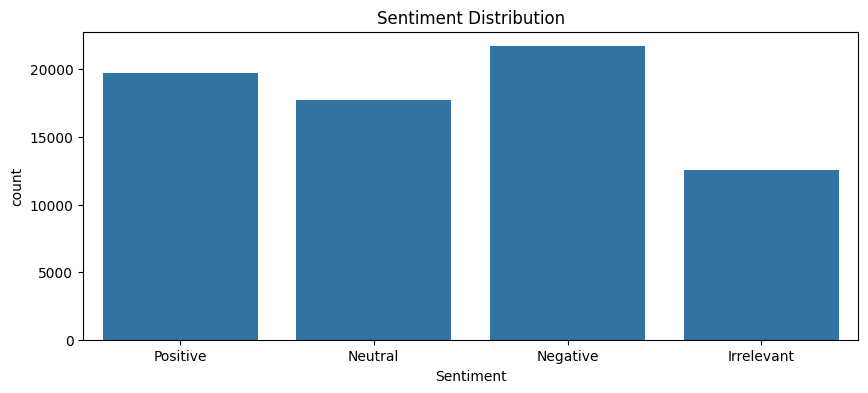

In [17]:
plt.figure(figsize=(10, 4))
sns.countplot(x='Sentiment', data=data)
plt.title('Sentiment Distribution')
plt.show()

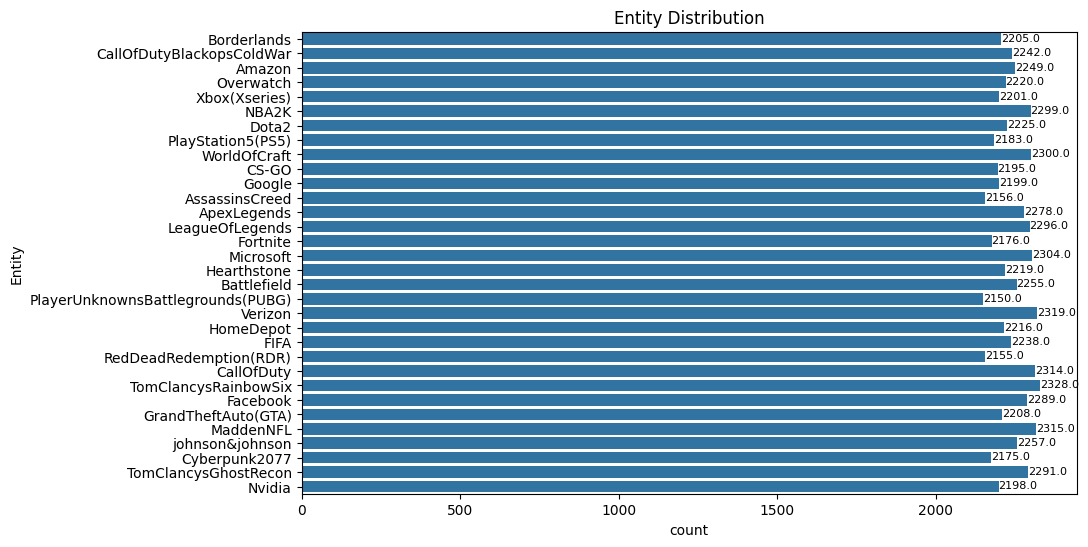

In [64]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Entity', data=data)
for bar in plt.gca().patches:
    plt.gca().annotate(f'{bar.get_width()}', (bar.get_x() + bar.get_width(), bar.get_y()), size=8, ha='left', va='top')
plt.title('Entity Distribution')
plt.show()

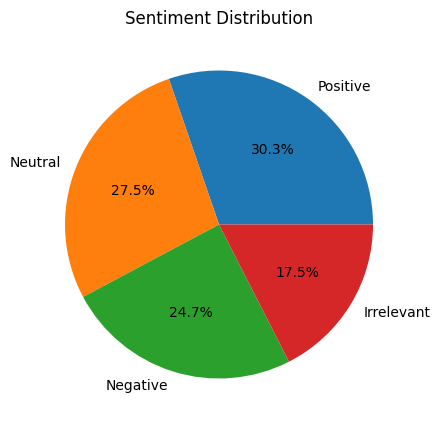

In [53]:
plt.figure(figsize=(10, 5))
plt.pie(data['Sentiment'].value_counts(), labels=data['Sentiment'].unique(), autopct='%1.1f%%')
plt.title('Sentiment Distribution')
plt.show()

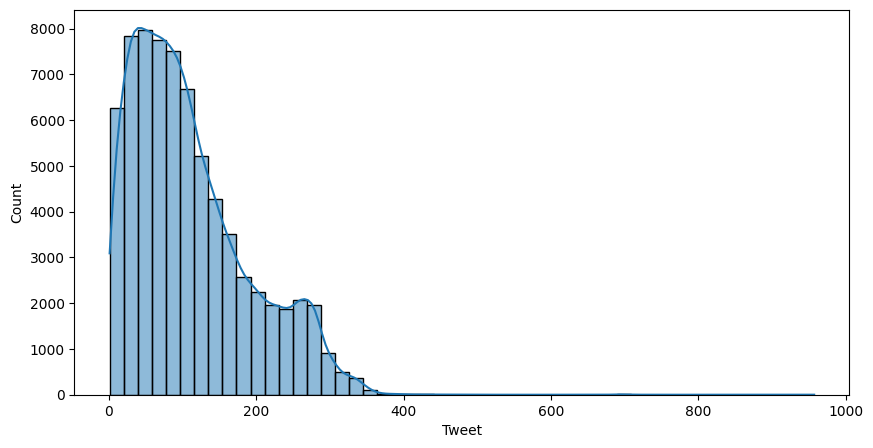

In [54]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Tweet'].str.len(), bins=50, kde=True)
plt.show()

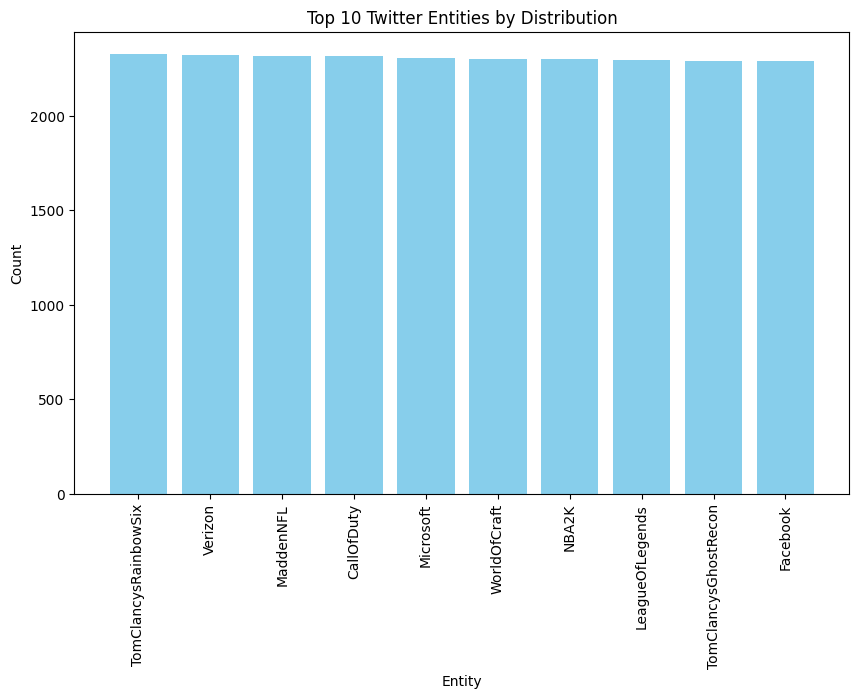

In [62]:
entity_distribution = data['Entity'].value_counts()

top_10_entities = entity_distribution.head(10)


plt.figure(figsize=(10,6))
plt.bar(top_10_entities.index, top_10_entities.values, color='skyblue')
plt.title('Top 10 Twitter Entities by Distribution')
plt.xlabel('Entity')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()


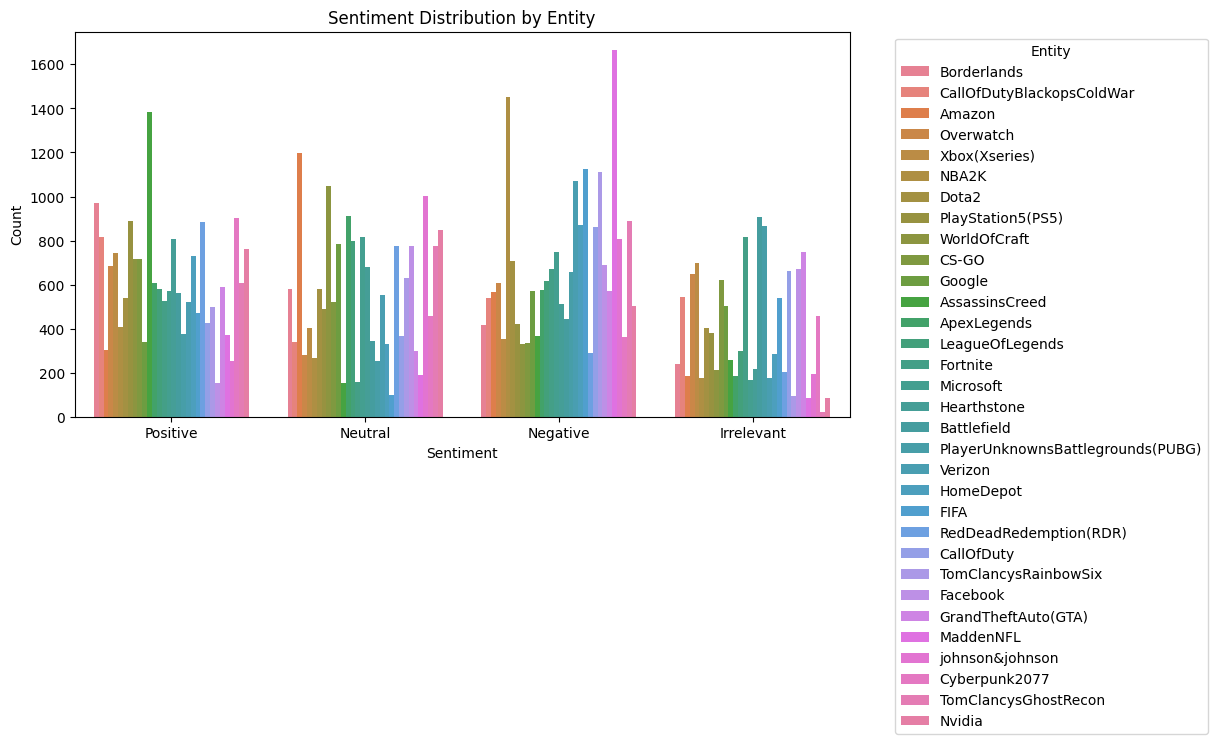

In [63]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x='Sentiment', hue='Entity')
plt.title("Sentiment Distribution by Entity")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.legend(title='Entity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

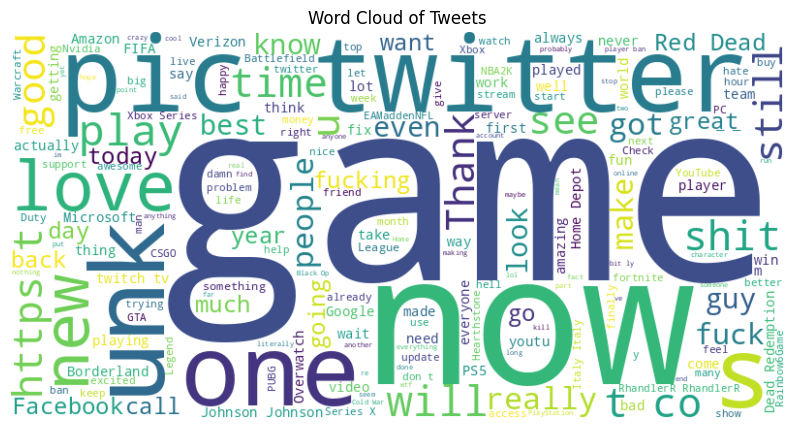

In [61]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(data['Tweet']))

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets')
plt.show()